<a href="https://colab.research.google.com/github/aditya03bairagi/Data-Science-Projects/blob/main/P3_House_Price_Prediction_Using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement - California Housing Price Prediction **
1. House prices in California depend on various factors such as income, population, location, and housing characteristics.

2. Predicting house prices manually can be difficult and time-consuming.

3. The goal of this project is to develop a Machine Learning model that predicts house prices based on available housing data.

4. This prediction can help buyers, sellers, and real estate companies make better pricing decisions.



---



In [ ]:
# import libraries

import pandas as pd                         # for data analysis
import matplotlib.pyplot as plt             # for data visualization
import seaborn as sb                        # for data visualization
import numpy as np                          # for numerical computation

from sklearn.datasets import fetch_california_housing               # for dataset
from sklearn.preprocessing import StandardScaler                    # for scaling
from sklearn.model_selection import train_test_split                # for train-test split
from sklearn.linear_model import LinearRegression, Lasso, Ridge     # for Linear Regression, Lasso Regression, Ridge Regression models
from sklearn.metrics import mean_squared_error, r2_score            # metrics for model evaluation


In [ ]:
# Load the data
housing = fetch_california_housing(as_frame=True) # returns a Pandas DataFrame with all data
df = housing.frame    # pandas Dataframe with 20640 rows and 9 columns (8 features + target)


'''
MedInc – Median income in the district (in 10,000s of dollars).
HouseAge – Median age of houses in the district.
AveRooms – Average number of rooms per household.
AveBedrms – Average number of bedrooms per household.
Population – Total population of the district.
AveOccup – Average number of household members.
Latitude – Latitude of the district (geographic location).
Longitude – Longitude of the district (geographic location).

Target (Dependent Variable)
MedHouseVal – Median value of houses (in $100,000s).
'''

'\nMedInc – Median income in the district (in 10,000s of dollars).\nHouseAge – Median age of houses in the district.\nAveRooms – Average number of rooms per household.\nAveBedrms – Average number of bedrooms per household.\nPopulation – Total population of the district.\nAveOccup – Average number of household members.\nLatitude – Latitude of the district (geographic location).\nLongitude – Longitude of the district (geographic location).\n\nTarget (Dependent Variable)\nMedHouseVal – Median value of houses (in $100,000s).\n'

In [ ]:
df.head() # show top 5 rows

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Data Exploration
df.shape  # number of rows, number of columns

(20640, 9)

In [ ]:
df.columns  # column names

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [ ]:
df.describe() # Statistical Analysis

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.info() # column names, non-null count, datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Check missing values
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


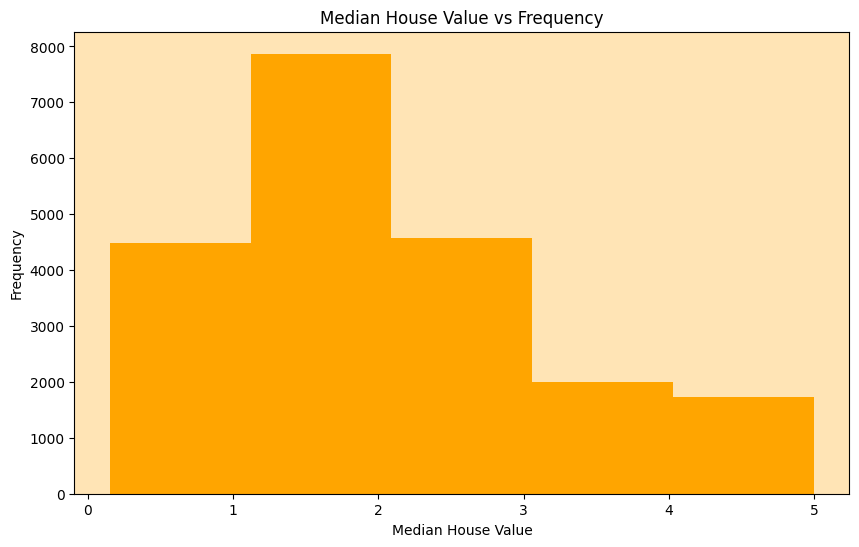

In [ ]:
# Data visualization
# distribution of target variable
plt.figure(figsize=(10, 6))
plt.hist(x=df['MedHouseVal'], bins=5, color='orange')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Median House Value vs Frequency')
ax = plt.gca() # get current axes(gca): get the axes (the actual chart area inside the figure)
ax.set_facecolor('moccasin') # changes background color of the plot
plt.show()

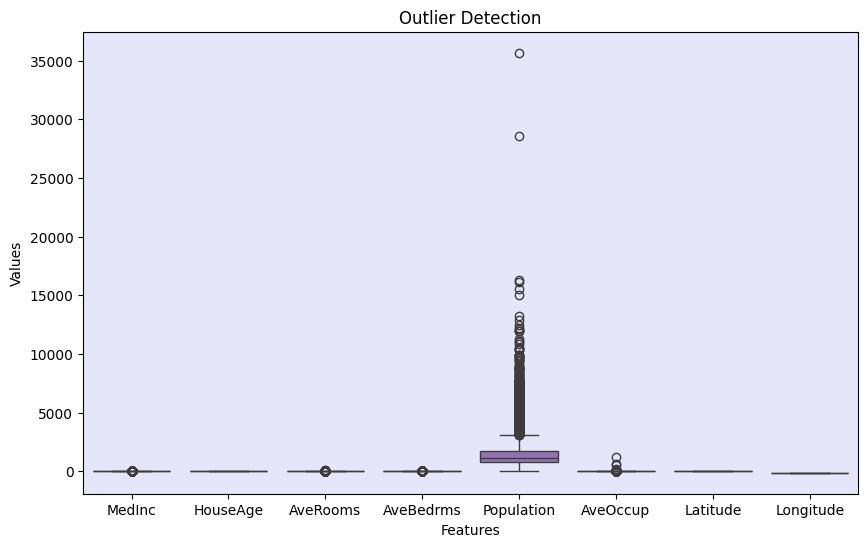

In [ ]:
# Outliers detection
plt.figure(figsize=(10,6))
sb.boxplot(df.drop('MedHouseVal', axis=1))
plt.xlabel('Features')
plt.ylabel('Values')
plt.title('Outlier Detection')
ax = plt.gca() # get current axes(gca): gets the axes (the actual chart area inside the figure)
ax.set_facecolor('lavender') # changes background color of the plot
plt.show()

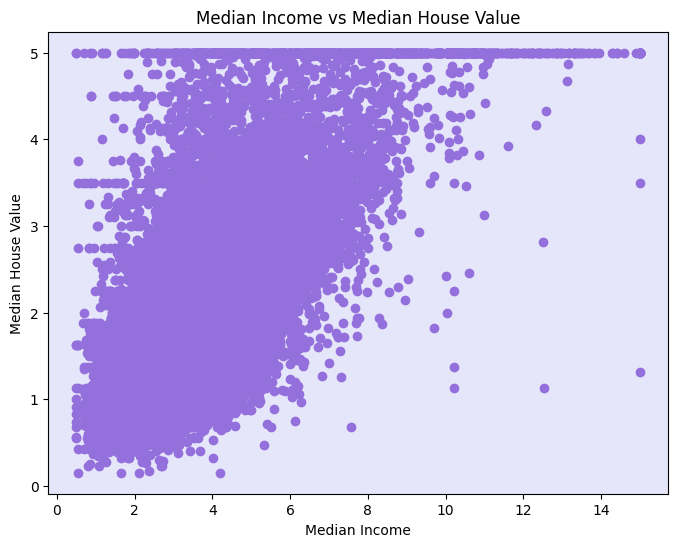

In [ ]:
# Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(df['MedInc'], df['MedHouseVal'], color='mediumpurple')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs Median House Value')
ax = plt.gca() # get current axes(gca): gets the axes (the actual chart area inside the figure)
ax.set_facecolor('lavender') # changes background color of the plot
plt.show()

In [ ]:
# Feature Selection
X = df.drop('MedHouseVal', axis=1) # select columns except target variable
y = df['MedHouseVal'] # select target variable


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,   # input, output
    test_size=0.2,  # test_size = 20%, training_size = 80%
    random_state=42 # for reproducibility of same results everytime
)

In [ ]:
# Feature Scaling: Scale numeric features to make them in a same range.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


'''
Consider the following example explaining fit_transform and transform:

for instance we have age and Sal columns.

fit:
mean of age
mean of Sal
SD of age
SD of Sal

feature mean  SD
age     37    10
Sal     65000 30000
------------------
transform
Xscaled = (x - mean) / SD

(40 - 37) / 10 = 0.3
(43000 - 65000) / 30000 = -0.73

'''


In [ ]:
# Train, Test, Evaluate the models

lin_model = LinearRegression() # Linear Regression model
lasso_model = Lasso(alpha=0.01) # Lasso Regression model (L1 Regularization)
ridge_model = Ridge(alpha=1.0) # Ridge Regression model (L2 Regularization)



def show():
  for model, name in zip([lin_model, lasso_model, ridge_model], ['Linear Regression', 'Lasso Regression', 'Ridge Regression']):
    model.fit(X_train_scaled, y_train)      # fit() method is used to train the model
    y_pred = model.predict(X_test_scaled)   # predict() method is used to test the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f'{name} : RMSE = {rmse}, R2 Score: {r2_score(y_test, y_pred)}')
    print('-' * 100)

show()





Linear Regression : RMSE = 0.7455813830127763, R2 Score: 0.575787706032451
----------------------------------------------------------------------------------------------------
Lasso Regression : RMSE = 0.7404423656125414, R2 Score: 0.5816154300698727
----------------------------------------------------------------------------------------------------
Ridge Regression : RMSE = 0.7455567442814779, R2 Score: 0.5758157428913684
----------------------------------------------------------------------------------------------------


## Linear Regression

### Definition

* **Linear Regression** is a **supervised machine learning algorithm**.
* It is used to **predict continuous numerical values**.
* It learns the relationship between **input (X)** and **output (Y)** using the equation:


    y = mx + c


Where:

* **y** = Predicted output
* **x** = Input feature
* **m** = Slope (rate of change of **y** with respect to **x**)
* **c** = Intercept (starting value of **y** when **x = 0**)

### Examples

* House Price prediction from **House Size**
* Salary prediction from **Years of Experience**
* Sales prediction from **Advertising Budget**

### Working

1. Collect training data.
2. Find the best-fit straight line.
3. Learn the values of **m** and **c**.
4. Use **(y = mx + c)** to predict the output for new input values.


---




## Ridge Regression

### Definition

* **Ridge Regression** is a **supervised machine learning algorithm**.
* It is an **improved version of Linear Regression**.
* It is used to **predict continuous numerical values**.
* It reduces **overfitting** by adding an **L2 penalty** to the cost function.

### Need

* Linear Regression may learn **very large coefficient values (m)**.
* Large coefficients can cause **overfitting**, where the model performs well on training data but poorly on new data.
* Ridge Regression keeps the coefficients **smaller**, improving generalization.

### Equation

Prediction equation (same as Linear Regression):

y = mx + c

Training cost function:

Cost = SSE + αΣm²


Where:

* **SSE** = Sum of Squared Errors
SSE = Σ (Actual - Predicted)²

* **α (alpha)** = Controls the penalty strength

* **m** = Coefficients (slope)

### How It Works

1. Collect training data.
2. Predict using **(y = mx + c)**.
3. Calculate **SSE**.
4. Add the penalty to get the total cost.
5. Update **m** and **c** to minimize the cost.
6. Repeat until the minimum cost is found.
7. Use the final equation **(y = mx + c)** to predict new values.

### Example

Suppose the model tries:

Try 1
Equation: y = 120x + 50
SSE = 10
Penalty = 20
Cost = 30

        ↓

Try 2
Equation: y = 110x + 50
SSE = 11
Penalty = 15
Cost = 26

        ↓

Try 3
Equation: y = 100x + 50
SSE = 11.5
Penalty = 12
Cost = 23.5

        ↓

Try 4
Equation: y = 90x + 50
SSE = 12
Penalty = 7
Cost = 19

        ↓

...

        ↓

Try n
Equation: y = 80x + 50
SSE = 13
Penalty = 4
Cost = 17  ✅ (Minimum Cost)

Ridge chooses **(y = 80x + 50)** because the **total cost is lower**, even though its SSE is slightly higher.

### Key Points

* Prediction equation remains **(y = mx + c)**.
* The **penalty is used only during training**, not during prediction.
* Ridge **reduces coefficient values** but **does not make them zero**.
* It helps **reduce overfitting**.


---




## Lasso Regression

### Definition

* **Lasso Regression** is a **supervised machine learning algorithm**.

* It is an **improved version of Linear Regression**.

* It is used to **predict continuous numerical values**.

* It reduces **overfitting** by adding an **L1 penalty** to the cost function.

* It performs **automatic feature selection** by making some coefficients exactly **zero**.

---

### Need

* Linear Regression may learn **very large coefficient values (m)**.

* Large coefficients can cause **overfitting**, where the model performs well on training data but poorly on new data.

* Lasso Regression keeps the coefficients smaller and removes **less important features** by making their coefficients **zero**.

---

### Equation

**Prediction equation (same as Linear Regression):**

```text
y = mx + c
```

**Training cost function:**

```text
Cost = SSE + αΣ|m|
```

Where:

* **SSE** = Sum of Squared Errors

```text
SSE = Σ (Actual - Predicted)²
```

* **α (alpha)** = Controls the penalty strength.
* **m** = Coefficients (slope).
* **|m|** = Absolute value of the coefficients.

---

### How It Works

1. Collect training data.
2. Predict using **y = mx + c**.
3. Calculate **SSE**.
4. Add the **L1 penalty** to get the total cost.
5. Update **m** and **c** to minimize the cost.
6. Repeat until the minimum cost is found.
7. Some coefficients become **exactly zero**, removing less important features.
8. Use the final equation **y = mx + c** to predict new values.

---

### Example

Suppose the model tries:

```text
Try 1
Equation:
House Price = 120 × House Size
            + 40 × Number of Bedrooms
            + 30 × Age of House
            + 50

SSE = 10
Penalty = 20
Cost = 30

        ↓

Try 2
Equation:
House Price = 100 × House Size
            + 20 × Number of Bedrooms
            + 28 × Age of House
            + 50

SSE = 11
Penalty = 12
Cost = 23

        ↓

Try 3
Equation:
House Price = 90 × House Size
            + 5 × Number of Bedrooms
            + 26 × Age of House
            + 50

SSE = 12
Penalty = 6
Cost = 18

        ↓

...

        ↓

Try n
Equation:
House Price = 80 × House Size
            + 0 × Number of Bedrooms
            + 25 × Age of House
            + 50

SSE = 13
Penalty = 3
Cost = 16 ✅ (Minimum Cost)
```

### Final Model

```text
House Price = 80 × House Size
            + 25 × Age of House
            + 50
```

Here,

* **Number of Bedrooms = 0**, so Lasso removes this feature from the model.

---

### Key Points

* Prediction equation remains **y = mx + c**.
* The **penalty is used only during training**, not during prediction.
* Lasso **reduces coefficients and can make some of them exactly zero**.
* It performs **automatic feature selection** by removing less important features.
* It helps **reduce overfitting**.


---




## Choosing Alpha (α) in Ridge and Lasso

### What is Alpha (α)?

* **α (alpha)** is the **regularization parameter**.
* It controls **how much penalty** is added to the cost function.

### Effect of Alpha

* **Small α**

  * Small penalty
  * Model behaves more like **Linear Regression**
  * Higher chance of **overfitting**

* **Large α**

  * Large penalty
  * Coefficients become smaller
  * Higher chance of **underfitting**

---

## Method 1: Hit and Trial (Manual Selection)

* Choose a value of **α** (e.g., **0.01**).
* Train the model.
* Evaluate its performance (e.g., using RMSE or R²).
* Try another value (e.g., **0.1**, **1**, **10**).
* Compare the results.
* Select the **α** that gives the best performance.

**Example:**

```text
α = 0.01 → RMSE = 3.2
α = 0.1  → RMSE = 2.8 ✅
α = 1    → RMSE = 3.1
```

> This method is simple but can be **time-consuming** because you manually try different values.

---

## Method 2: Cross-Validation (Recommended)

* Provide multiple alpha values (e.g., **0.001, 0.01, 0.1, 1, 10, 100**).
* The algorithm automatically:

  1. Trains the model for each α.
  2. Evaluates each using **Cross-Validation**.
  3. Compares their performance.
  4. Selects the **best α**.

**Scikit-learn:**

```python
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
```

These classes automatically find the best alpha.

---

## Key Points

* **Small α** → Less regularization → Risk of **overfitting**.
* **Large α** → More regularization → Risk of **underfitting**.
* **Hit and Trial** → You manually test different alpha values and choose the best.
* **Cross-Validation (RidgeCV/LassoCV)** → The algorithm automatically tests multiple alpha values and selects the best one.
* **Cross-Validation is the preferred method** because it is more reliable and reduces the chance of choosing a poor alpha.


---



# Regression Evaluation Metrics

## 1. MAE (Mean Absolute Error)

### Definition

* Measures the **average absolute difference** between actual and predicted values.
* Treats **all errors equally**.

### Formula

```text
MAE = Σ|Actual − Predicted| / n
```

### Key Points

* Same unit as the target variable.
* Easy to understand.
* Does **not focus more on** large errors.
* **Lower MAE is better.**

---

## 2. MSE (Mean Squared Error)

### Definition

* Measures the **average squared difference** between actual and predicted values.
* Gives **more importance to** large errors.

### Formula

```text
MSE = Σ(Actual − Predicted)² / n
```

### Key Points

* Gives **more importance to** large errors.
* Unit is **squared** (e.g., ₹²), so it is difficult to interpret.
* Commonly used during model training and optimization.
* **Lower MSE is better.**

---

## 3. RMSE (Root Mean Squared Error)

### Definition

* Square root of MSE.
* Measures the **average prediction error**.

### Formula

```text
RMSE = √MSE
```

### Key Points

* Gives **more importance to** large errors.
* Same unit as the target variable.
* Easier to interpret than MSE.
* Most commonly used regression error metric.
* **Lower RMSE is better.**

---

## 4. R² Score (Coefficient of Determination)

### Definition

* Measures **how well the model explains the variation** in the target variable.

### Formula

```text
R² = 1 − (SSE / SST)
```

Where:

```text
SSE = Σ(Actual − Predicted)²
SST = Σ(Actual − Mean of Actual Values)²
```

### Key Points

* Shows how well the model fits the data.
* Range:

  * **1** → Perfect model.
  * **0** → Model predicts no better than the mean.
  * **< 0** → Model performs worse than predicting the mean.
* **Higher R² is better.**

---

# Which Metrics Are Mostly Used?

The **most commonly used regression metrics are:**

1. **RMSE**
2. **R² Score**

---

## Why RMSE?

* Measures the **prediction error**.
* Gives **more importance to** large errors.
* Same unit as the target variable.
* Easier to understand than MSE.
* Preferred over MSE because MSE has **squared units**, which are difficult to interpret.

**Example:**

Target = House Price (₹)

```text
MSE = ₹² ❌ (hard to interpret)

RMSE = ₹50,000 ✅
```

Meaning:

> On average, the model's predictions are about **₹50,000** away from the actual values.

---

## Why R² Score?

* Measures **how well the model fits the data**.
* Shows **how much variation** in the target variable is explained by the model.
* Easy to compare different regression models.

**Example:**

```text
R² = 0.90
```

Meaning:

> The model explains **90% of the variation** in the target variable.

---

## Why Use Both RMSE and R² Score?

* **RMSE** tells **how much error** the model makes.
* **R² Score** tells **how well the model fits the data**.

Using **both metrics together** provides a more complete evaluation of a regression model than using only one metric.

---


> **We usually use RMSE and R² Score together for regression models. RMSE measures the average prediction error in the same unit as the target variable, making it easy to interpret. R² Score measures how well the model explains the variation in the target variable. Together, they provide a complete evaluation of the model's performance.**


---

